In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [14]:
df = pd.read_csv('../data/q3_retail_promotions.csv')

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
df.head()

Shape: (1200, 9)

Data Types:
 transaction_date         str
store_id               int64
store_size               str
location_type            str
promotion_type           str
is_weekend             int64
is_festival            int64
competition_density    int64
items_sold             int64
dtype: object


,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [15]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df['year']        = df['transaction_date'].dt.year
df['month']       = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

print("New columns added: year, month, day_of_week, is_month_end")
df[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].head(10)

New columns added: year, month, day_of_week, is_month_end


,transaction_date,year,month,day_of_week,is_month_end
0,2022-01-01,2022,1,5,0
1,2022-01-01,2022,1,5,0
2,2022-01-02,2022,1,6,0
3,2022-01-02,2022,1,6,0
4,2022-01-03,2022,1,0,0
5,2022-01-03,2022,1,0,0
6,2022-01-04,2022,1,1,0
7,2022-01-04,2022,1,1,0
8,2022-01-05,2022,1,2,0
9,2022-01-05,2022,1,2,0


In [16]:
df = df.sort_values('transaction_date').reset_index(drop=True)

split_index = int(len(df) * 0.8)
train = df.iloc[:split_index]
test  = df.iloc[split_index:]

print(f"Total rows   : {len(df)}")
print(f"Training rows: {len(train)}  ({train['transaction_date'].min().date()} to {train['transaction_date'].max().date()})")
print(f"Test rows    : {len(test)}   ({test['transaction_date'].min().date()} to {test['transaction_date'].max().date()})")

Total rows   : 1200
Training rows: 960  (2022-01-01 to 2024-06-11)
Test rows    : 240   (2024-06-12 to 2024-12-31)


### Why a Random Split is Inappropriate for Time-Ordered Data

A random split randomly scatters records from all time periods into both train and test sets. This causes **data leakage** — the model would be trained on data from, say, December 2023 and tested on January 2023, meaning it has effectively "seen the future" during training.

In reality, a deployed model always predicts future data it has never seen. A temporal split — where training uses only past records and testing uses only future records — honestly replicates this real-world condition.

Using a random split would produce overly optimistic evaluation metrics that do not reflect true out-of-sample predictive performance.

In [17]:
cat_cols  = ['promotion_type', 'location_type', 'store_size']
num_cols  = ['year', 'month', 'day_of_week', 'is_weekend',
             'is_festival', 'competition_density', 'is_month_end']
drop_cols = ['transaction_date', 'store_id', 'items_sold']

X_train = train.drop(columns=drop_cols)
y_train = train['items_sold']
X_test  = test.drop(columns=drop_cols)
y_test  = test['items_sold']

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape: (960, 10)
X_test shape : (240, 10)


In [18]:
preprocessor = ColumnTransformer(transformers=[
    ('ohe',    OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('scaler', StandardScaler(),                                            num_cols)
])

In [19]:
pipelines = {
    'Linear Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('model',        LinearRegression())
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('model',        RandomForestRegressor(random_state=42))
    ])
}

results = {}
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    mae   = mean_absolute_error(y_test, preds)
    results[name] = {'preds': preds, 'rmse': rmse, 'mae': mae}
    print(f"{name}")
    print(f"  RMSE : {rmse:.2f}")
    print(f"  MAE  : {mae:.2f}\n")

Linear Regression
  RMSE : 27.13
  MAE  : 21.07

Random Forest
  RMSE : 31.23
  MAE  : 25.00



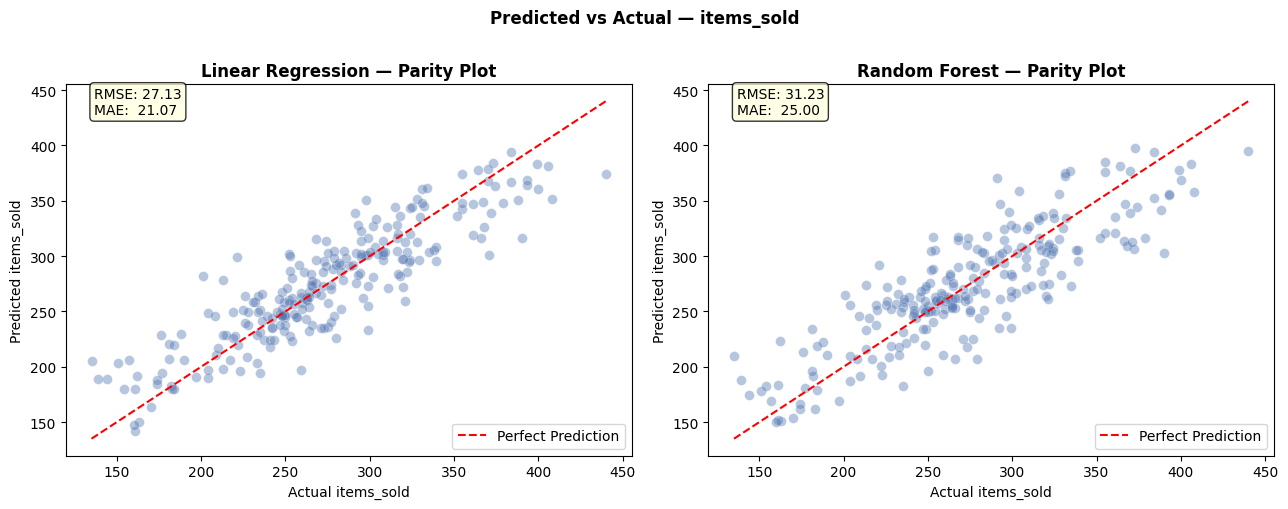

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, res) in zip(axes, results.items()):
    preds = res['preds']
    ax.scatter(y_test, preds, alpha=0.4, color='#4C72B0',
               edgecolors='white', linewidths=0.3, s=50)

    min_val = min(y_test.min(), preds.min())
    max_val = max(y_test.max(), preds.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            color='red', linewidth=1.5, linestyle='--', label='Perfect Prediction')

    ax.set_title(f'{name} — Parity Plot', fontweight='bold')
    ax.set_xlabel('Actual items_sold')
    ax.set_ylabel('Predicted items_sold')
    ax.legend()
    ax.text(0.05, 0.92, f'RMSE: {res["rmse"]:.2f}\nMAE:  {res["mae"]:.2f}',
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Predicted vs Actual — items_sold', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [21]:
rf_pipe = pipelines['Random Forest']

ohe_features = (rf_pipe.named_steps['preprocessor']
                        .named_transformers_['ohe']
                        .get_feature_names_out(cat_cols)
                        .tolist())
all_features = ohe_features + num_cols

importances = pd.Series(
    rf_pipe.named_steps['model'].feature_importances_,
    index=all_features
).sort_values(ascending=False)

print("Top 5 Most Influential Features:")
print(importances.head(5).round(4).to_string())

Top 5 Most Influential Features:
is_festival            0.1735
store_size_small       0.1679
location_type_urban    0.1090
day_of_week            0.0838
is_weekend             0.0710


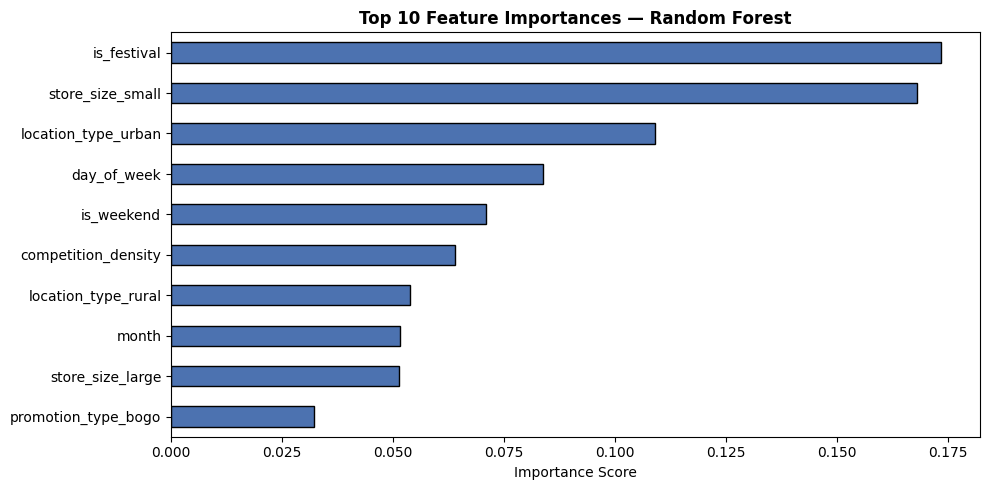

In [22]:
plt.figure(figsize=(10, 5))
importances.head(10).sort_values().plot(
    kind='barh', color='#4C72B0', edgecolor='black'
)
plt.title('Top 10 Feature Importances — Random Forest', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()